In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df.shape

(119390, 32)

In [6]:
df.duplicated().sum()

np.int64(31994)

In [7]:
df.isnull().sum()[df.isnull().sum() > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [8]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### removing duplicate rows

In [9]:
df = df.drop_duplicates()

### handle missing values

In [10]:
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)

In [11]:
df.drop(columns=['company'], inplace=True)

### data types correction

In [12]:
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

### removing invalid rows

In [13]:
# bookings with zero guests
zero_guests = (df['adults'] + df['children'] + df['babies']) == 0
print('Zero Guests:', zero_guests.sum())

# bookings with negative or extreme adr
bad_adr = (df['adr'] < 0) | (df['adr'] >= 5000)
print('Bad ADR:', bad_adr.sum())

Zero Guests: 166
Bad ADR: 2


In [14]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df = df[df['total_guests'] > 0]

In [15]:
df = df[df['adr'] >= 0]
df = df[df['adr'] < 5000]

### month order

In [16]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

### new columns

In [17]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

df['revenue'] = df['adr'] * df['total_nights']

### removing zero-night bookings

In [18]:
df = df[df['total_nights'] > 0]

In [19]:
df.shape

(86637, 35)

In [20]:
df.isnull().sum().sum()

np.int64(0)

## **Exploratory Data Analysis**

### Q1. How many bookings does each hotel get, and what share is cancelled?

In [21]:
df['hotel'].value_counts()

hotel
City Hotel      53042
Resort Hotel    33595
Name: count, dtype: int64

In [22]:
df['is_canceled'].mean() * 100

np.float64(27.68447660930088)

In [23]:
df.groupby('hotel')['is_canceled'].mean() * 100

hotel
City Hotel      30.204366
Resort Hotel    23.705909
Name: is_canceled, dtype: float64

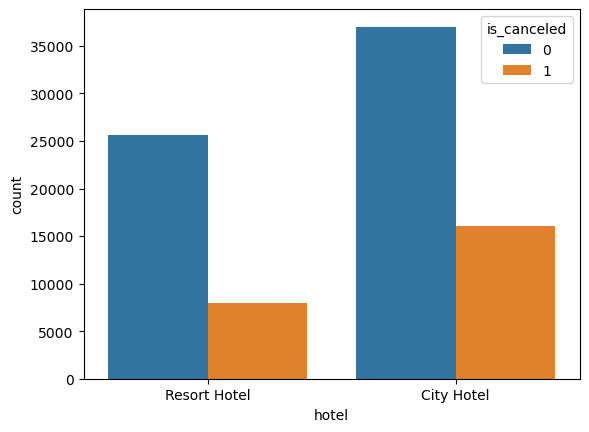

In [24]:
sns.countplot(data=df, x='hotel', hue='is_canceled')
plt.show()

#### Insight
City Hotel gets 53,042 bookings and Resort Hotel gets 33,595 bookings. Overall 27.68% of bookings are cancelled. City Hotel's 30% bookings are cancelled and Resort Hotel's 23% bookings are cancelled.

### Q2. Which months are busiest, and which earn the most revenue?

In [47]:
df['arrival_date_month'].value_counts()

arrival_date_month
August       11194
July          9988
May           8296
April         7870
June          7721
March         7438
October       6842
September     6659
February      6030
December      5045
November      4916
January       4638
Name: count, dtype: int64

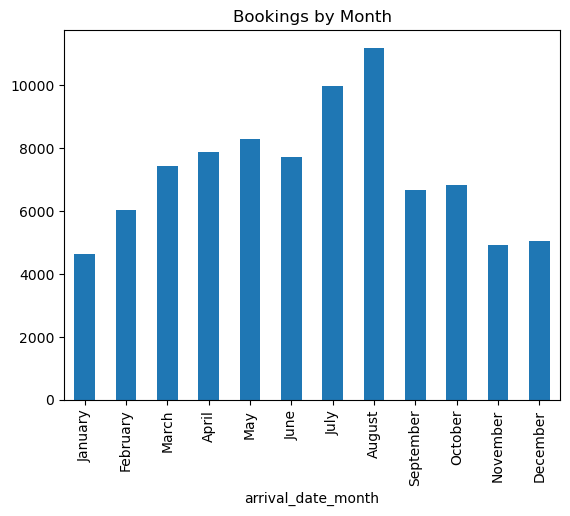

In [25]:
df['arrival_date_month'].value_counts().sort_index().plot(kind='bar')
plt.title('Bookings by Month')
plt.show()

In [52]:
df[df['is_canceled'] == 0].groupby('arrival_date_month', observed=True)['revenue'].sum().sort_values(ascending=False)

arrival_date_month
August       4606618.30
July         3798500.20
June         2295647.03
May          2059809.09
September    1969859.31
April        1804556.70
October      1476094.71
March        1415734.71
February     1024202.26
December      919684.45
November      891885.64
January       705019.55
Name: revenue, dtype: float64

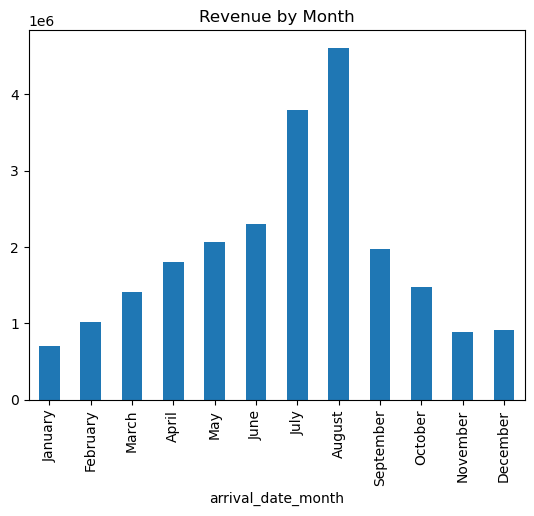

In [26]:
df[df['is_canceled'] == 0].groupby('arrival_date_month', observed=True)['revenue'].sum().plot(kind='bar')
plt.title('Revenue by Month')
plt.show()

#### Insight
The months August, July and May are the top 3 busiest months and also they earn most revenue, with August at about 4.6M July at about 3.7M and June comes third in revenue at about 2.2M.

### Q3. How does lead time relate to cancellation?

In [27]:
df.groupby('is_canceled')['lead_time'].mean()

is_canceled
0     70.518738
1    105.822097
Name: lead_time, dtype: float64

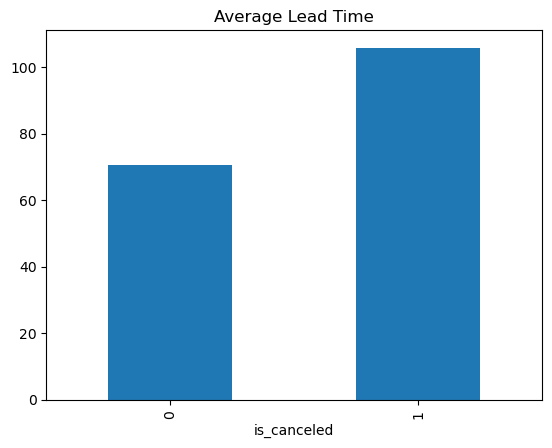

In [28]:
df.groupby('is_canceled')['lead_time'].mean().plot(kind='bar')
plt.title('Average Lead Time')
plt.show()

#### Insight
Cancelled bookings have a much longer average lead time (105.8 days) than bookings that stayed (70.5 days). The earlier a guest books, the more likely they are to cancel.

### Q4. Which market segments and distribution channels bring the most bookings and the most cancellations?

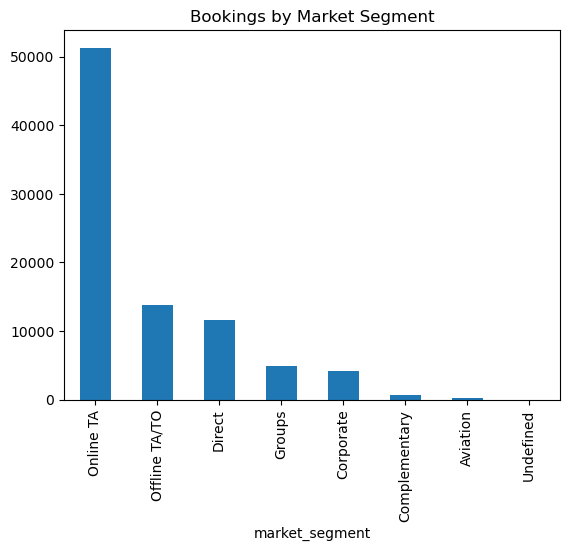

In [29]:
df['market_segment'].value_counts().plot(kind='bar')
plt.title('Bookings by Market Segment')
plt.show()

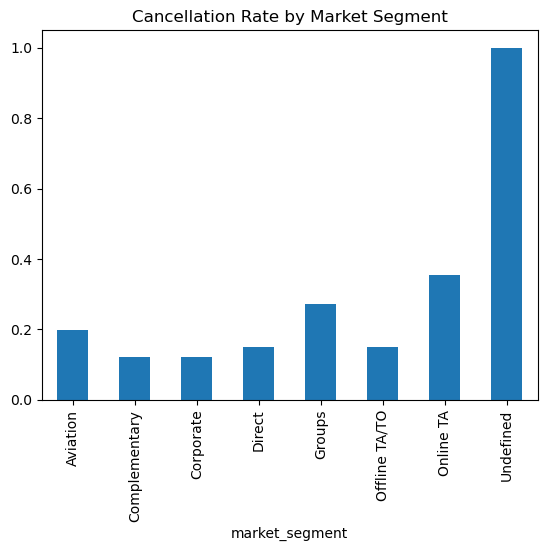

In [30]:
df.groupby('market_segment')['is_canceled'].mean().plot(kind='bar', title='Cancellation Rate by Market Segment')
plt.show()

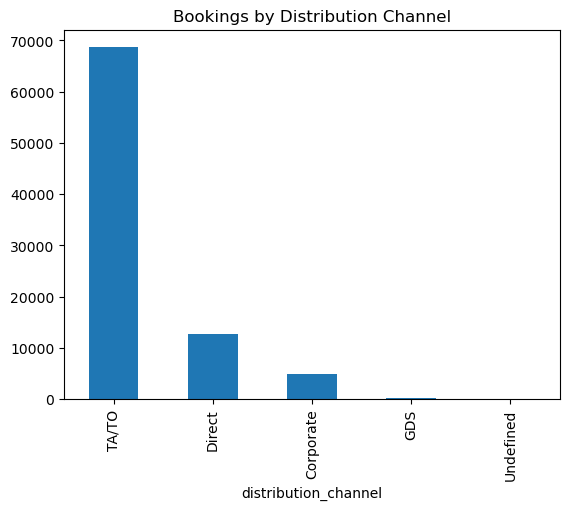

In [31]:
df['distribution_channel'].value_counts().plot(kind='bar', title='Bookings by Distribution Channel')
plt.show()

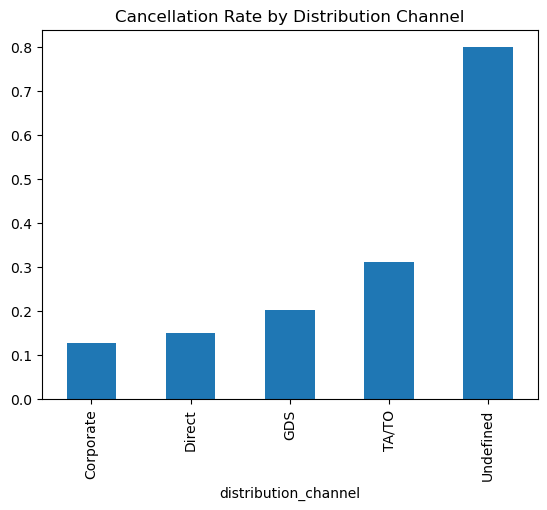

In [32]:
df.groupby('distribution_channel')['is_canceled'].mean().plot(kind='bar', title='Cancellation Rate by Distribution Channel')
plt.show()

#### Insight
Market Segment: Online TA brings the highest bookings and Undefined the highest cancellation (Undefined has only 2 count)

Distribution Channel: TA/TO brings the highest bookings and Undefined the highest cancellation (Undefined has only 5 count)

### Q5. Does deposit type affect cancellation?

In [33]:
df.groupby('deposit_type')['is_canceled'].value_counts(normalize=True) * 100

deposit_type  is_canceled
No Deposit    0              73.124115
              1              26.875885
Non Refund    1              94.696239
              0               5.303761
Refundable    0              75.700935
              1              24.299065
Name: proportion, dtype: float64

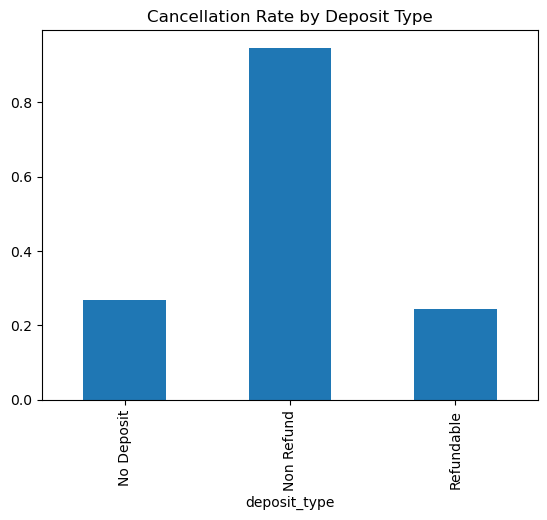

In [34]:
df.groupby('deposit_type')['is_canceled'].mean().plot(kind='bar', title='Cancellation Rate by Deposit Type')
plt.show()

#### Insight
Customers with Non Refund deposit type cancelled 94.7% of the time, compared with No Deposit which is 26.87% and Refundable 24.29%.

### Q6. How does ADR change across months and between the two hotels?

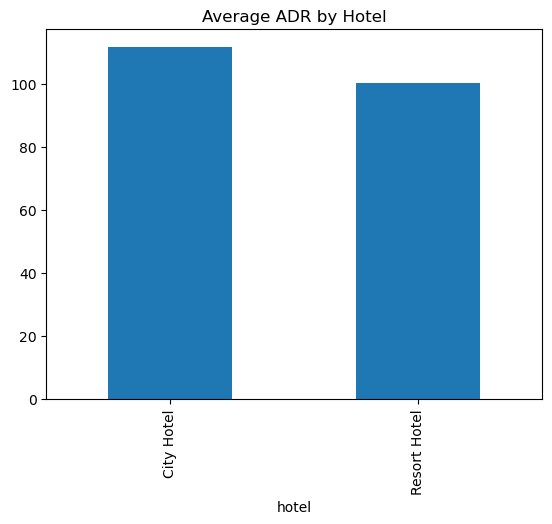

In [35]:
df.groupby('hotel')['adr'].mean().plot(kind='bar', title='Average ADR by Hotel')
plt.show()

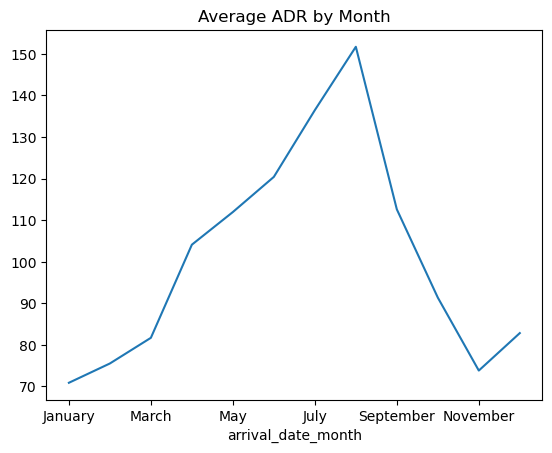

In [36]:
df.groupby('arrival_date_month',observed = True)['adr'].mean().plot(kind='line', title='Average ADR by Month')
plt.show()

#### Insight
City Hotel has the highest ADR(Average Daily Rate) and the ADR was highest from the month of June to August.

### Q7. What is the typical length of stay, and does it differ by hotel?

In [37]:
df['total_nights'].describe()

count    86637.000000
mean         3.653243
std          2.735743
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         69.000000
Name: total_nights, dtype: float64

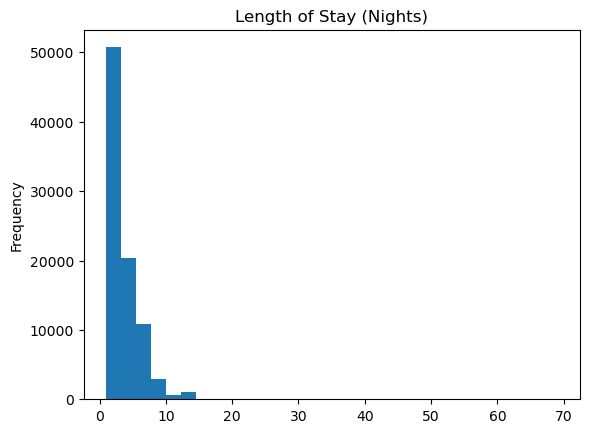

In [38]:
df['total_nights'].plot(kind='hist', bins=30, title='Length of Stay (Nights)')
plt.show()

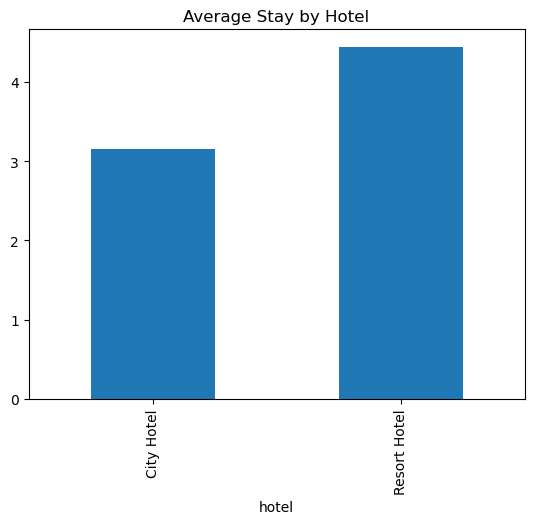

In [39]:
df.groupby('hotel')['total_nights'].mean().plot(kind='bar', title='Average Stay by Hotel')
plt.show()

#### Insight
Resort Hotel has stay longer on average than City Hotel guests.

### Q8. Which countries do guests come from?

In [40]:
(df['country'].value_counts(normalize=True) * 100).head(5)

country
PRT    31.006383
GBR    12.004109
FRA    10.172328
ESP     8.342856
DEU     6.215589
Name: proportion, dtype: float64

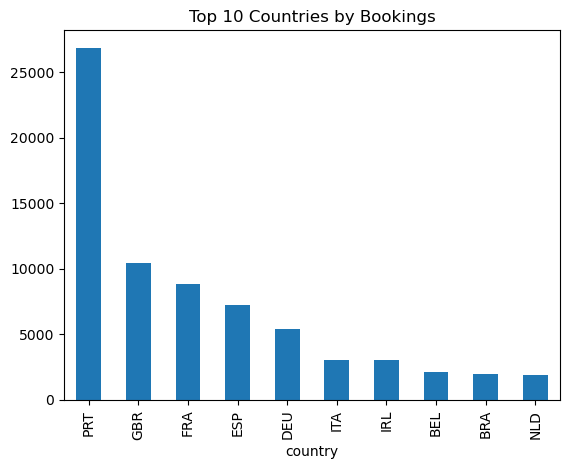

In [41]:
df['country'].value_counts().head(10).plot(kind='bar', title='Top 10 Countries by Bookings')
plt.show()

#### Insight
Most customers are from Portugal that is 31%

### Q9. Do repeat guests cancel less?

In [42]:
(df.groupby('is_repeated_guest')['is_canceled'].value_counts(normalize=True) * 100)

is_repeated_guest  is_canceled
0                  0              71.583246
                   1              28.416754
1                  0              91.762087
                   1               8.237913
Name: proportion, dtype: float64

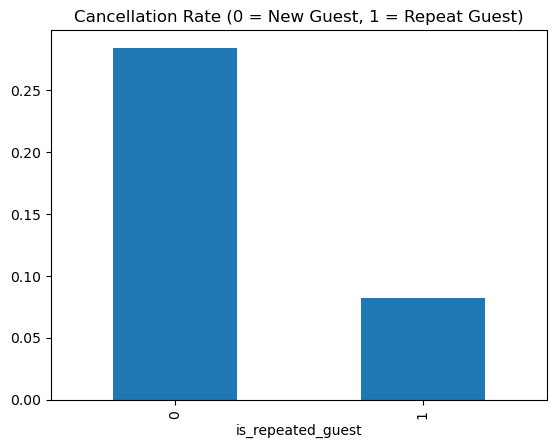

In [43]:
df.groupby('is_repeated_guest')['is_canceled'].mean().plot(kind='bar', title='Cancellation Rate (0 = New Guest, 1 = Repeat Guest)')
plt.show()

#### Insight
Yes, repeated guest cancels less than new guest. New guest cancelled 28% of the time while the repeated guest cancelled just 8% of the time.

### Q10. Do special requests or parking spaces relate to cancellation?

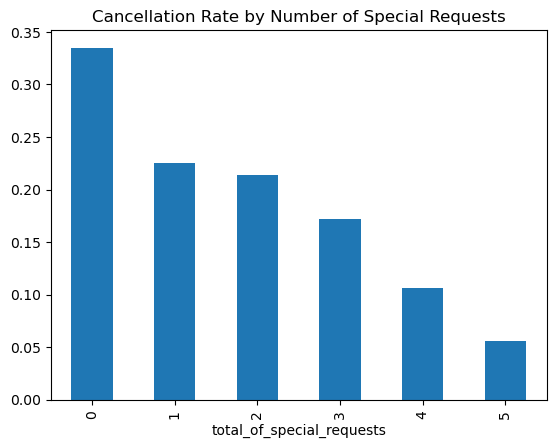

In [44]:
df.groupby('total_of_special_requests')['is_canceled'].mean().plot(kind='bar', title='Cancellation Rate by Number of Special Requests')
plt.show()

In [45]:
df['required_car_parking_spaces'].value_counts()

required_car_parking_spaces
0    79347
1     7257
2       28
3        3
8        2
Name: count, dtype: int64

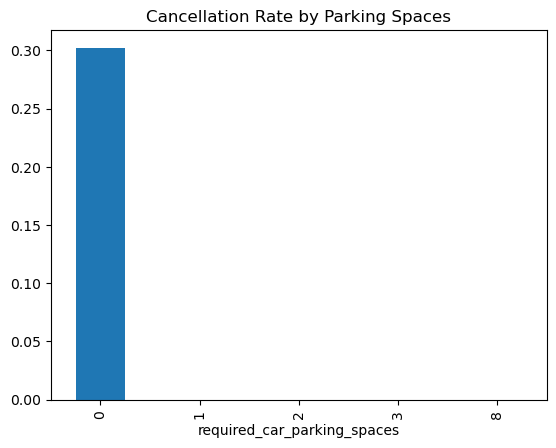

In [46]:
df.groupby('required_car_parking_spaces')['is_canceled'].mean().plot(kind='bar', title='Cancellation Rate by Parking Spaces')
plt.show()

#### Insight
Guests with no special requests cancel the most, and the cancellation rate declines as the number of requests increases. Guests who require a parking space almost never cancel.

## **Conclusion**

**Key findings**

1. **Cancellations are a major issue:** 27.7% of all bookings are cancelled. City Hotel cancels more (30.2%) than Resort Hotel (23.7%).
2. **Lead time matters:** cancelled bookings were made about 35 days earlier on average (105.8 days vs 70.5 days).
3. **Travel agents bring volume but also risk:** Online TA is the biggest booking source and cancels more than Direct, Corporate and Offline TA/TO bookings.
4. **Repeat guests are the most reliable:** only 8.2% of repeat guests cancel, compared with 28.4% of new guests.
5. **Pricing is seasonal:** ADR peaks in August (about 150) and is lowest in winter (about 70). City Hotel has a higher average ADR than Resort Hotel.
6. **Stay length differs by hotel:** the typical stay is 3 nights, and Resort guests stay longer on average than City guests.
7. **Portugal is the main market:** 31% of bookings come from Portugal, and the top 5 countries (all European) make up about 68%.
8. **Summer is peak season:** August and July have the most bookings and the highest revenue.
9. **Commitment signals matter:** cancellation drops as special requests rise (about 33% with none, about 5% with five), and guests who need parking rarely cancel.

**Recommendations**

- Ask for deposits, or send reminders, on bookings made far in advance.
- Encourage direct and repeat bookings, since they cancel far less.
- Keep an eye on online travel agent bookings, which are the largest group but the least reliable.

**Limitations**

- The data covers July 2015 to August 2017 for two hotels in Portugal, so the findings may not apply elsewhere.
- Deposit type, particularly "Non Refund", behaves oddly in this dataset and shouldn't be read as a cause.
- July and August appear in three years of data and other months in two, so they look busier partly for that reason.